# Hyperparameter Tuning: Learning Rate Optimisation for Task 1d

## Setup and Data Preprocessing

In [9]:
import tensorflow as tf
from tensorflow import keras

layers = keras.layers
Sequential = keras.models.Sequential
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
seed = 42

# Learning rate range and step
start_lr = 0.00001
end_lr = 50
lr_step = 2
learning_rates = []
while start_lr <= end_lr:
    learning_rates.append(start_lr)
    start_lr *= lr_step
print(learning_rates)

# Optimal learning rates
best_learning_rates = {}
best_metrics = {}

# Get preprocessed data using existing function
# training_data, test_data = pre_processing(seed=seed)
tf.keras.utils.set_random_seed(seed)

# Define arrays with the equivalent step size
x_arr = np.arange(-1, 1.05, 0.05)  # Start: -1, End: 1 (inclusive), Step: 0.05
x_test = np.arange(-0.97, 0.94, 0.1)  # Start: -0.97, End: 0.93 (inclusive), Step: 0.1

# Generate training data
X_train = x_arr.reshape(-1, 1)  # Reshape to (n_samples, 1)
noise_train = np.random.normal(0, 0.02, len(x_arr))  # Generate random noise
y_train = 0.8 * x_arr**3 + 0.3 * x_arr**2 - 0.4 * x_arr + noise_train

# Generate test data
X_test = x_test.reshape(-1, 1)  # Reshape to (n_samples, 1)
noise_test = np.random.normal(0, 0.02, len(x_test))  # Generate random noise
y_test = 0.8 * x_test**3 + 0.3 * x_test**2 - 0.4 * x_test + noise_test

# Convert labels to categorical
# y_train = keras.utils.to_categorical(y_train)
# y_test = keras.utils.to_categorical(y_test)

[1e-05, 2e-05, 4e-05, 8e-05, 0.00016, 0.00032, 0.00064, 0.00128, 0.00256, 0.00512, 0.01024, 0.02048, 0.04096, 0.08192, 0.16384, 0.32768, 0.65536, 1.31072, 2.62144, 5.24288, 10.48576, 20.97152, 41.94304]


## Define Model Creation and Training Function with Different Learning Rates

In [10]:
def create_and_train_model(architecture, activation_functions, learning_rate, n_trials=10):
    """
    Creates and trains a neural network with specified architecture multiple times.
    
    Args:
        architecture (list): List of integers representing neurons in each hidden layer
        activation_functions (list): Activation functions for each layer (including output)
        learning_rate (float): Learning rate for SGD optimizer
        n_trials (int): Number of training runs for averaging results
    
    Returns:
        tuple: (final model, averaged training history with standard deviations)
    """
    
    all_histories = []

    for trial in range(n_trials):
        # Create new model for each trial
        model = Sequential()
        # Generate unique but reproducible seed for each combination of trial and learning rate
        kernel_initializer = tf.keras.initializers.GlorotUniform(
            seed=42 + trial + hash(str(learning_rate)) % 1000000
        )

        # Input Layer
        model.add(layers.Input(shape=(1,)))

        # Add hidden layers according to specified architecture
        for units, activation in zip(architecture, activation_functions[:-1]):
            model.add(
                layers.Dense(
                    units, activation=activation, kernel_initializer=kernel_initializer
                )
            )

        # Add output layer with linear activation for regression
        model.add(
            layers.Dense(
                1,
                activation=activation_functions[-1],
                kernel_initializer=kernel_initializer,
            )
        )

        # Compile model with MSE loss and MAE metric
        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
            loss="mean_squared_error",
            metrics=["mean_absolute_error"],
        )

        # Train the model
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_test, y_test),
            epochs=50,
            batch_size=16,
            verbose=0,
            shuffle=False,
        )

        all_histories.append(history.history)

    # Calculate mean and standard deviation across all trials
    avg_history = {
        "mean_absolute_error": np.mean(
            [h["mean_absolute_error"] for h in all_histories], axis=0
        ),
        "val_mean_absolute_error": np.mean(
            [h["val_mean_absolute_error"] for h in all_histories], axis=0
        ),
        "loss": np.mean([h["loss"] for h in all_histories], axis=0),
        "val_loss": np.mean([h["val_loss"] for h in all_histories], axis=0),
        "std_mean_absolute_error": np.std(
            [h["mean_absolute_error"] for h in all_histories], axis=0
        ),
        "std_val_mean_absolute_error": np.std(
            [h["val_mean_absolute_error"] for h in all_histories], axis=0
        ),
        "std_loss": np.std([h["loss"] for h in all_histories], axis=0),
        "std_val_loss": np.std([h["val_loss"] for h in all_histories], axis=0),
    }

    return model, avg_history

## Define Experiments

In [11]:
# Define different architectures to test
experiments = {
    "original": {
        "architecture": [3],
        "activations": ["tanh", "linear"],
        "description": "1-3-1 (original)",
    },
    "smaller": {
        "architecture": [1],
        "activations": ["tanh", "linear"],
        "description": "1-1-1 (smaller)",
    },
    "relu_based": {
        "architecture": [3],
        "activations": ["relu", "linear"],
        "description": "1-3-1 (ReLU)",
    },
    "large": {
        "architecture": [64],
        "activations": ["relu", "linear"],
        "description": "1-64-1 (large)",
    },
    "deep": {
        "architecture": [4, 8, 16],
        "activations": ["sigmoid", "tanh", "sigmoid", "tanh"],
        "description": "1-4-8-16-1 (deep)",
    },
}

## Train Models and Store Results Regarding Learning Rates


Testing 1-3-1 (original)...
Testing learning rate: 0.000010
Testing learning rate: 0.000020
Testing learning rate: 0.000040
Testing learning rate: 0.000080
Testing learning rate: 0.000160
Testing learning rate: 0.000320
Testing learning rate: 0.000640
Testing learning rate: 0.001280
Testing learning rate: 0.002560
Testing learning rate: 0.005120
Testing learning rate: 0.010240
Testing learning rate: 0.020480
Testing learning rate: 0.040960
Testing learning rate: 0.081920
Testing learning rate: 0.163840
Testing learning rate: 0.327680
Testing learning rate: 0.655360


/Users/s.hsu/miniconda3/lib/python3.11/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Testing learning rate: 1.310720
Testing learning rate: 2.621440
Testing learning rate: 5.242880
Testing learning rate: 10.485760
Testing learning rate: 20.971520
Testing learning rate: 41.943040


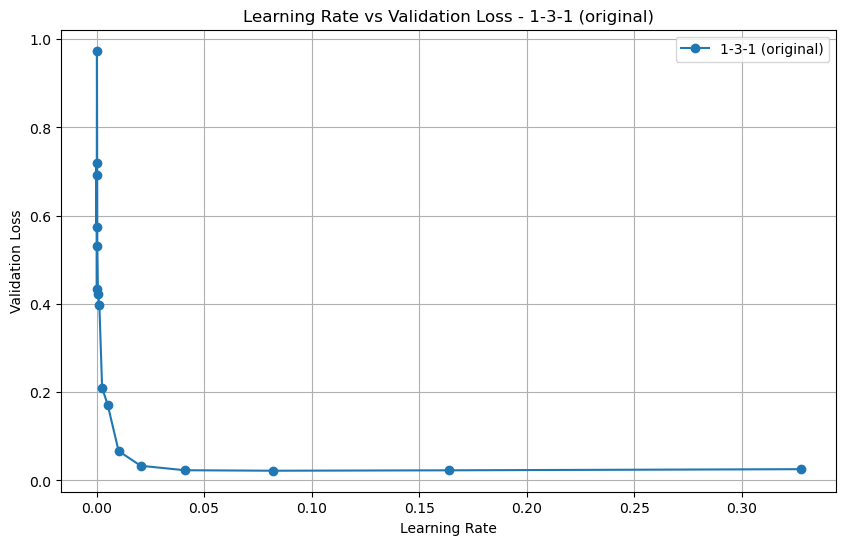


Testing 1-1-1 (smaller)...
Testing learning rate: 0.000010
Testing learning rate: 0.000020
Testing learning rate: 0.000040
Testing learning rate: 0.000080
Testing learning rate: 0.000160
Testing learning rate: 0.000320
Testing learning rate: 0.000640
Testing learning rate: 0.001280
Testing learning rate: 0.002560
Testing learning rate: 0.005120
Testing learning rate: 0.010240
Testing learning rate: 0.020480
Testing learning rate: 0.040960
Testing learning rate: 0.081920
Testing learning rate: 0.163840
Testing learning rate: 0.327680
Testing learning rate: 0.655360
Testing learning rate: 1.310720
Testing learning rate: 2.621440
Testing learning rate: 5.242880
Testing learning rate: 10.485760
Testing learning rate: 20.971520
Testing learning rate: 41.943040


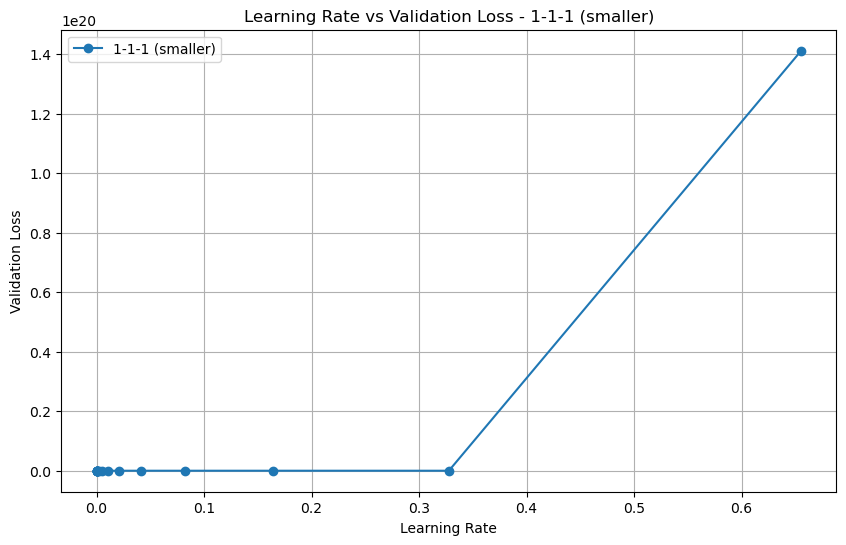


Testing 1-3-1 (ReLU)...
Testing learning rate: 0.000010
Testing learning rate: 0.000020
Testing learning rate: 0.000040
Testing learning rate: 0.000080
Testing learning rate: 0.000160
Testing learning rate: 0.000320
Testing learning rate: 0.000640
Testing learning rate: 0.001280
Testing learning rate: 0.002560
Testing learning rate: 0.005120
Testing learning rate: 0.010240
Testing learning rate: 0.020480
Testing learning rate: 0.040960
Testing learning rate: 0.081920
Testing learning rate: 0.163840
Testing learning rate: 0.327680
Testing learning rate: 0.655360
Testing learning rate: 1.310720
Testing learning rate: 2.621440
Testing learning rate: 5.242880
Testing learning rate: 10.485760
Testing learning rate: 20.971520
Testing learning rate: 41.943040


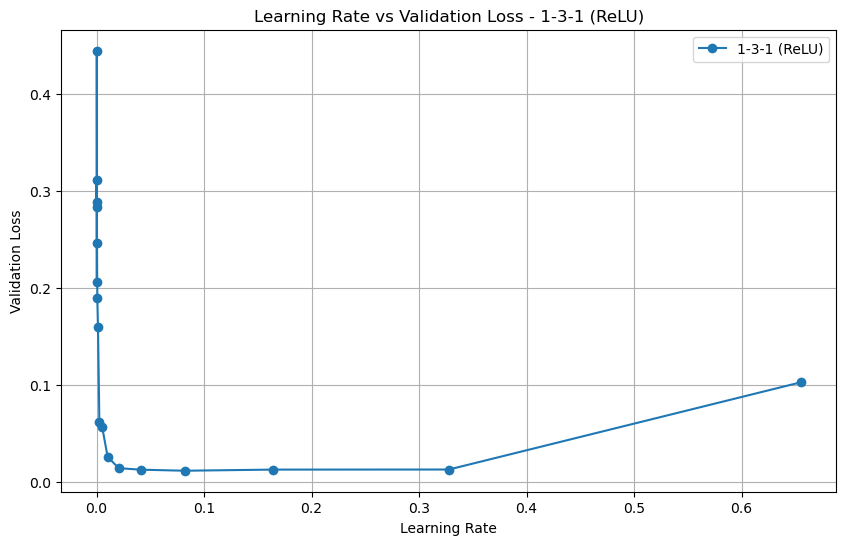


Testing 1-64-1 (large)...
Testing learning rate: 0.000010
Testing learning rate: 0.000020
Testing learning rate: 0.000040
Testing learning rate: 0.000080
Testing learning rate: 0.000160
Testing learning rate: 0.000320
Testing learning rate: 0.000640
Testing learning rate: 0.001280
Testing learning rate: 0.002560
Testing learning rate: 0.005120
Testing learning rate: 0.010240
Testing learning rate: 0.020480
Testing learning rate: 0.040960
Testing learning rate: 0.081920
Testing learning rate: 0.163840
Testing learning rate: 0.327680
Testing learning rate: 0.655360
Testing learning rate: 1.310720
Testing learning rate: 2.621440
Testing learning rate: 5.242880
Testing learning rate: 10.485760
Testing learning rate: 20.971520
Testing learning rate: 41.943040


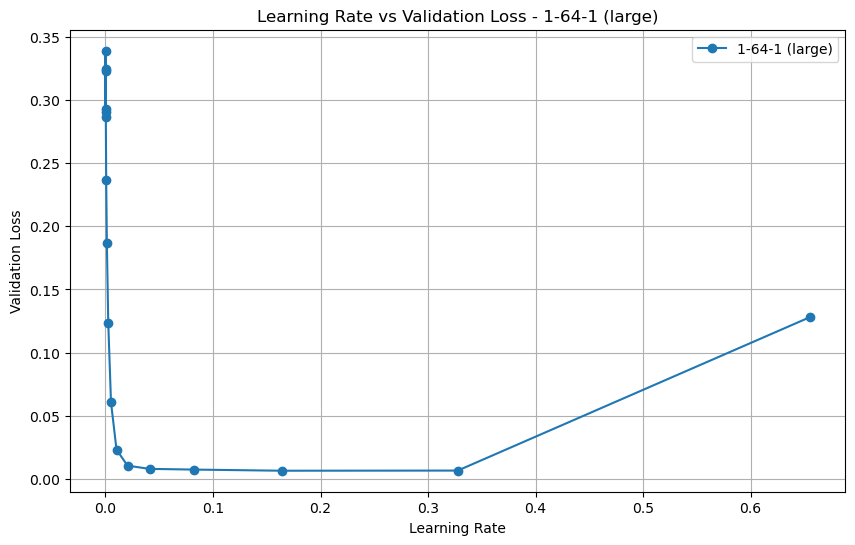


Testing 4-6-4-4-3 (deep)...
Testing learning rate: 0.000010
Testing learning rate: 0.000020
Testing learning rate: 0.000040
Testing learning rate: 0.000080
Testing learning rate: 0.000160
Testing learning rate: 0.000320
Testing learning rate: 0.000640
Testing learning rate: 0.001280
Testing learning rate: 0.002560
Testing learning rate: 0.005120
Testing learning rate: 0.010240
Testing learning rate: 0.020480
Testing learning rate: 0.040960
Testing learning rate: 0.081920
Testing learning rate: 0.163840
Testing learning rate: 0.327680
Testing learning rate: 0.655360
Testing learning rate: 1.310720
Testing learning rate: 2.621440
Testing learning rate: 5.242880
Testing learning rate: 10.485760
Testing learning rate: 20.971520
Testing learning rate: 41.943040


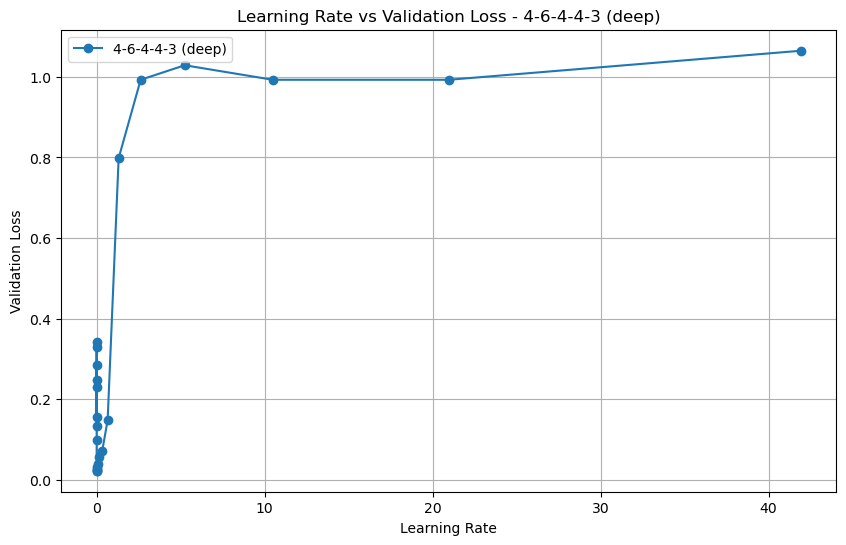

In [12]:
# Dictionary to store validation loss for each learning rate and architecture
learning_rate_results = {}

# Test each architecture with different learning rates
for name, config in experiments.items():
    print(f"\nTesting {config['description']}...")
    best_val_loss = float("inf")
    best_lr = None
    best_history = None
    learning_rate_results[name] = []

    # Try each learning rate in the defined range
    for lr in learning_rates:
        try:
            print(f"Testing learning rate: {lr:.6f}")
            _, history = create_and_train_model(
                config["architecture"],
                config["activations"],
                learning_rate=lr,
                n_trials=10,
            )

            # Store and update best results based on validation loss
            val_loss = history["val_loss"][-1]
            learning_rate_results[name].append((lr, val_loss))
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_lr = lr
                best_history = history
        except Exception as e:
            print(f"Error with learning rate {lr:.6f}: {e}")

    # Plot learning rate vs validation loss if results exist
    if learning_rate_results[name]:
        lrs, losses = zip(*learning_rate_results[name])
        plt.figure(figsize=(10, 6))
        plt.plot(lrs, losses, "-o", label=config["description"])
        plt.xlabel("Learning Rate")
        plt.ylabel("Validation Loss")
        plt.title(f'Learning Rate vs Validation Loss - {config["description"]}')
        plt.grid(True)
        plt.legend()
        plt.show()
    else:
        print(f"No valid results for {config['description']}. Skipping plot.")

    # Store the best results if any were found
    if best_history:
        best_learning_rates[name] = best_lr
        best_metrics[name] = {
            "val_loss": best_val_loss,
            "train_loss": best_history["loss"][-1],
            "val_std": best_history["std_val_loss"][-1],
            "train_std": best_history["std_loss"][-1],
        }

## Output Results Regarding Optimal Hyperparameters

In [13]:
# Print results
print("\nOptimal Learning Rates and Performance:")
for name, lr in best_learning_rates.items():
    metrics = best_metrics[name]
    print(f"\n{experiments[name]['description']}:")
    print(f"Best Learning Rate: {lr:.6f}")
    print(
        f"Validation Accuracy: {metrics['val_accuracy']:.4f} ± {metrics['val_std']:.4f}"
    )
    print(
        f"Training Accuracy: {metrics['train_accuracy']:.4f} ± {metrics['train_std']:.4f}"
    )


Optimal Learning Rates and Performance:

1-3-1 (original):
Best Learning Rate: 0.081920


KeyError: 'val_accuracy'